Employee attrition costs organisations 50-200% of an employee's annual salary in recruiting, onboarding, and lost productivity.

In [1]:
project_goal = """
This analysis identifies the key drivers of voluntary attrition among IBM employees and builds a predictive model to flag at-risk employees, enabling HR to intervene proactively.
"""
print(project_goal)


This analysis identifies the key drivers of voluntary attrition among IBM employees and builds a predictive model to flag at-risk employees, enabling HR to intervene proactively.



# Research questions :
1. What individual, job, and organisational factors are independently associated with attrition after adjustment for confounders?
2. Which employee profile has the highest predicted probability of leaving in the next year?
3. What is the minimum set of features that gives 80% of the predictive gain?
4. Does overtime moderate the relationship between job satisfaction and attrition?


In [2]:
#  importing tools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score, classification_report
from scipy import stats
import shap
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [3]:
# load dataset
df = pd.read_csv("HR_Employee_Attrition")
df

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,...,3,80,1,17,3,3,5,2,0,3
1466,1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,...,1,80,1,9,5,3,7,7,1,7
1467,1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,...,2,80,1,6,0,3,6,2,0,3
1468,1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,...,4,80,0,17,3,2,9,6,0,8


In [4]:
df.shape

(1470, 36)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Attrition                 1470 non-null   object
 3   BusinessTravel            1470 non-null   object
 4   DailyRate                 1470 non-null   int64 
 5   Department                1470 non-null   object
 6   DistanceFromHome          1470 non-null   int64 
 7   Education                 1470 non-null   int64 
 8   EducationField            1470 non-null   object
 9   EmployeeCount             1470 non-null   int64 
 10  EmployeeNumber            1470 non-null   int64 
 11  EnvironmentSatisfaction   1470 non-null   int64 
 12  Gender                    1470 non-null   object
 13  HourlyRate                1470 non-null   int64 
 14  JobInvolvement          

In [6]:
df.head(10)

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2
5,5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,...,3,80,0,8,2,2,7,7,3,6
6,6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,...,1,80,3,12,3,2,1,0,0,0
7,7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,...,2,80,1,1,2,3,1,0,0,0
8,8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,...,2,80,0,10,2,3,9,7,1,8
9,9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,...,2,80,2,17,3,2,7,7,7,7


In [7]:
df.describe()

,Unnamed: 0,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,734.500000,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,424.496761,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,0.000000,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,367.250000,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,734.500000,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1101.750000,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,1469.000000,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.columns

Index(['Unnamed: 0', 'Age', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate',
       'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [9]:
# encoding categorical variable properly (overtime and attrition must become binary)
df["Attrition"] = df["Attrition"].map({"Yes":1, "No":0})
df["OverTime"] = df["OverTime"].map({"Yes": 1, "No": 0})
df["Attrition"]
df["OverTime"]

0       1
1       0
2       1
3       1
4       0
       ..
1465    0
1466    0
1467    1
1468    0
1469    0
Name: OverTime, Length: 1470, dtype: int64

In [10]:
# check prevalence
df["Attrition"].mean()

np.float64(0.16122448979591836)

In [11]:
# computing class balance
df["Attrition"].value_counts(normalize=True)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

# We check imbalance because :
severely imbalance outcomes can bias logistic regression estimates.



In [12]:
# Initial data quality audit
df.isnull().sum()

Unnamed: 0                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCur

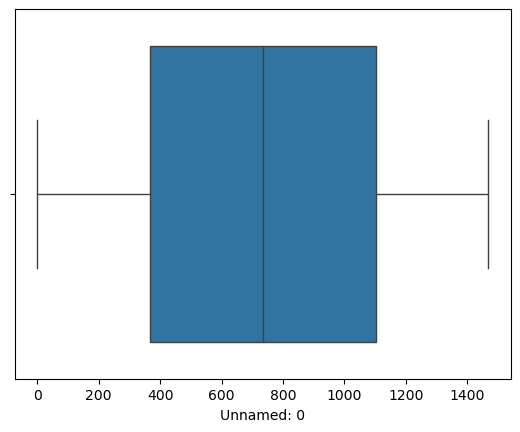

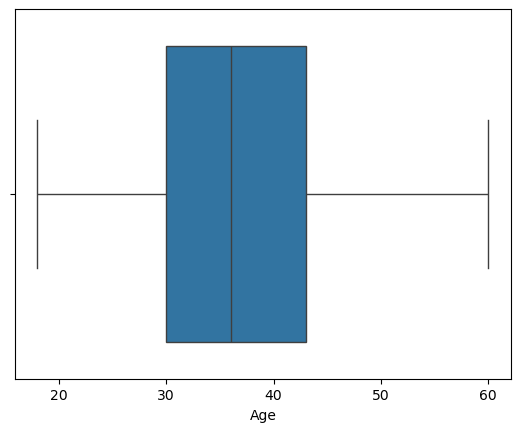

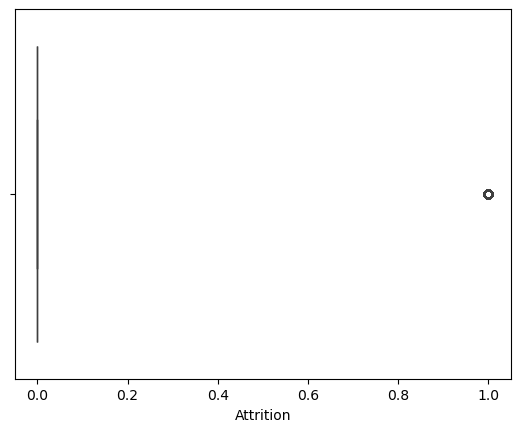

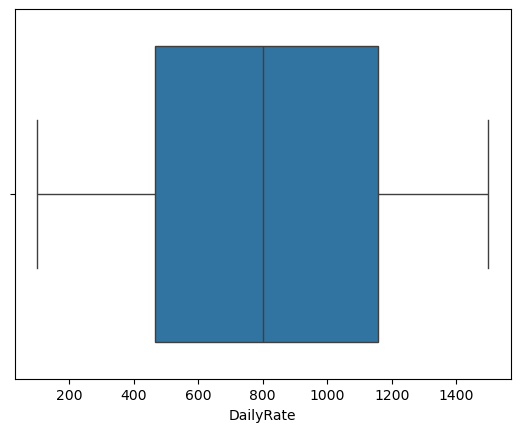

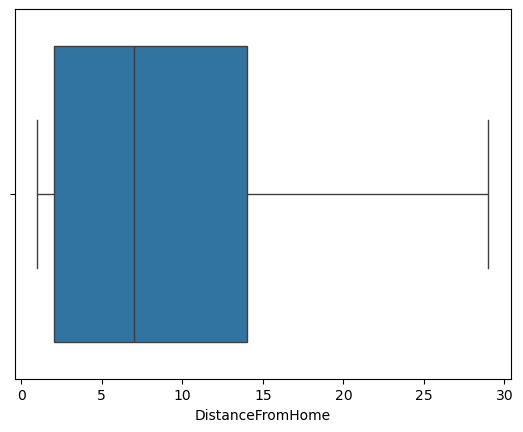

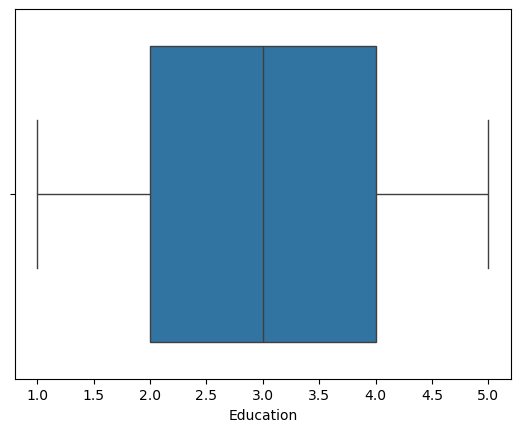

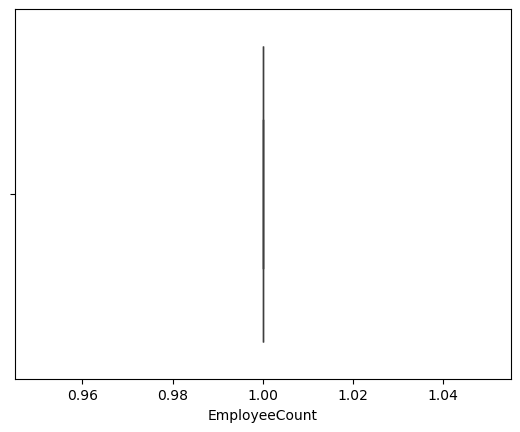

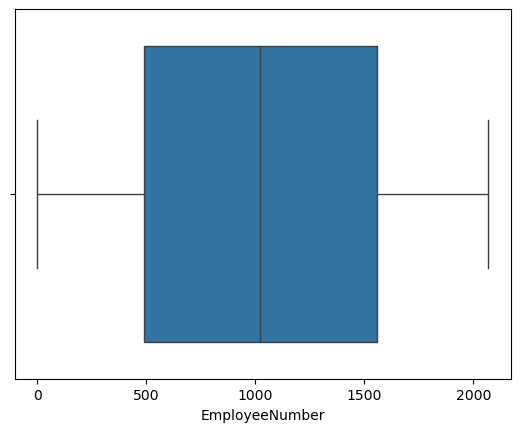

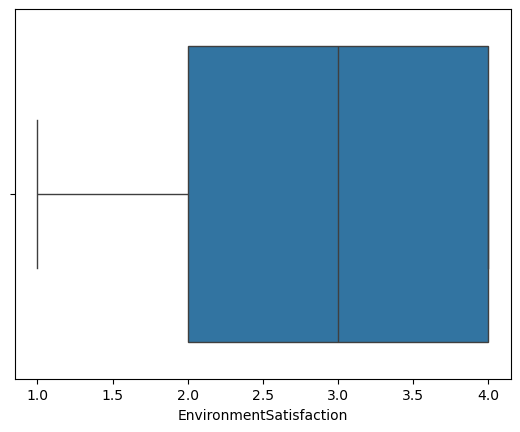

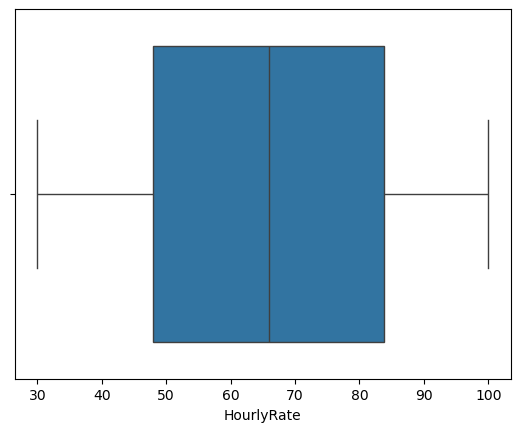

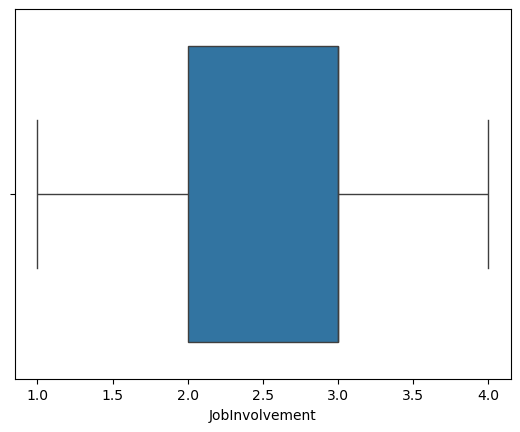

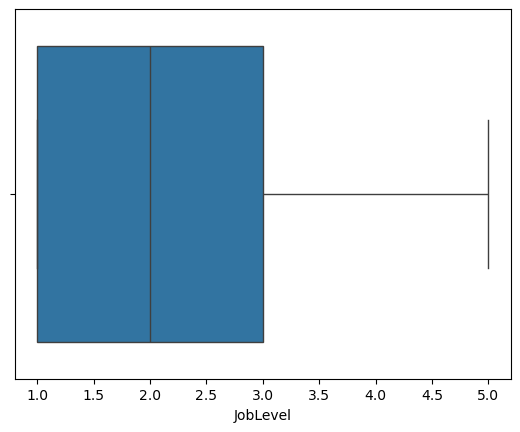

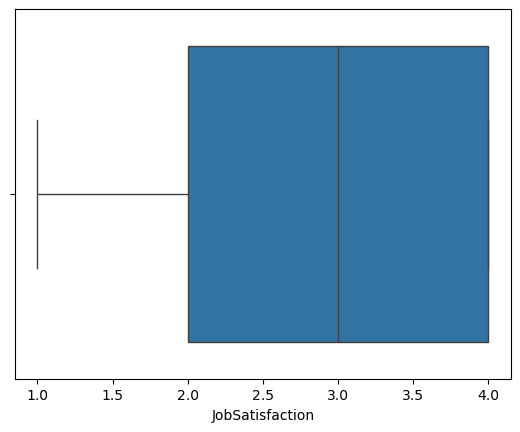

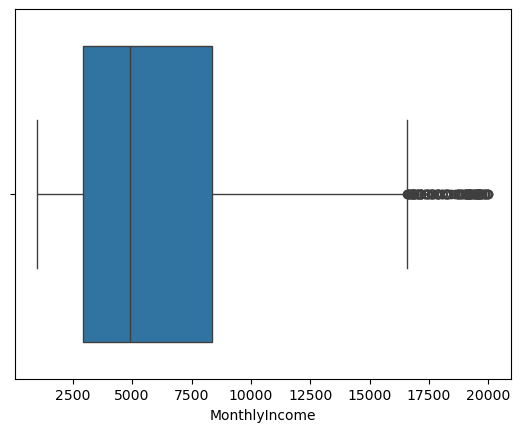

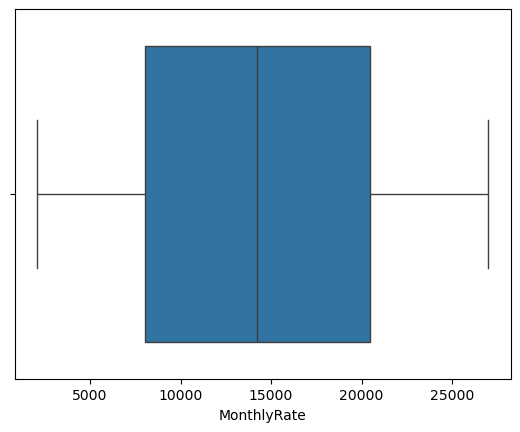

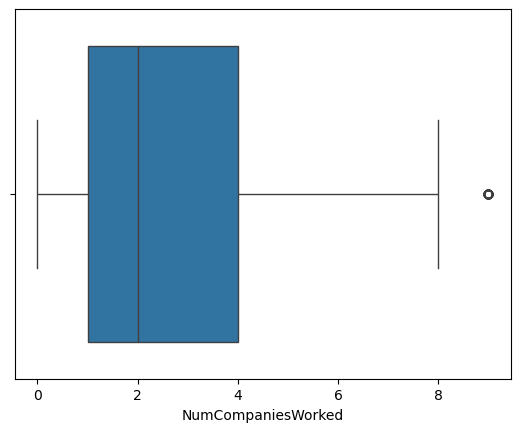

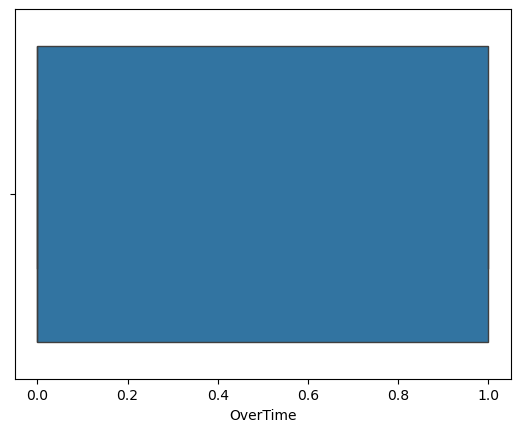

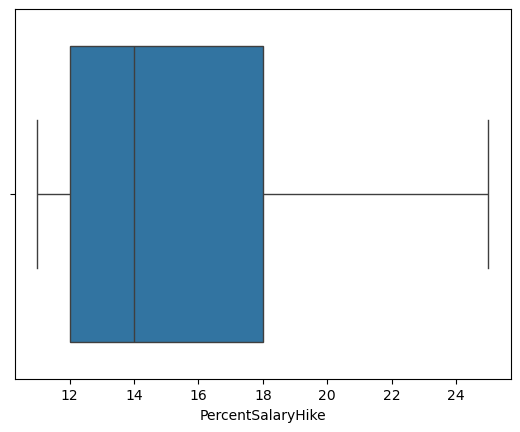

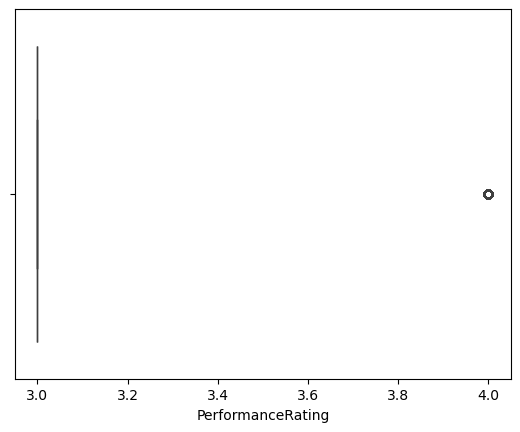

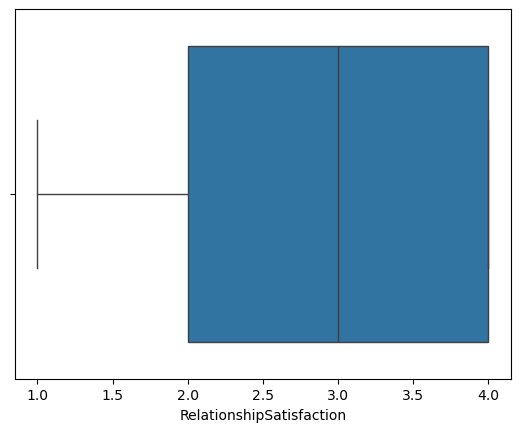

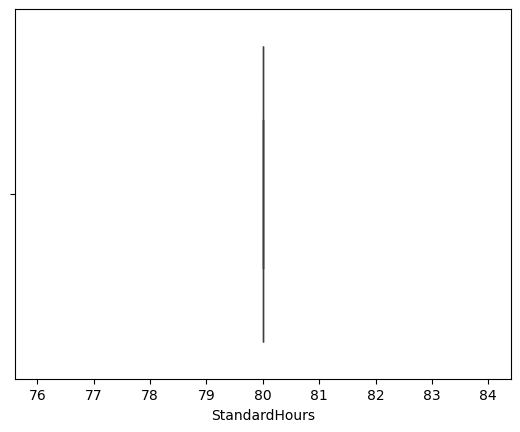

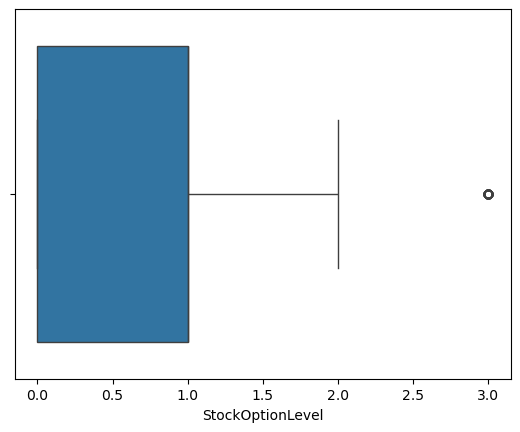

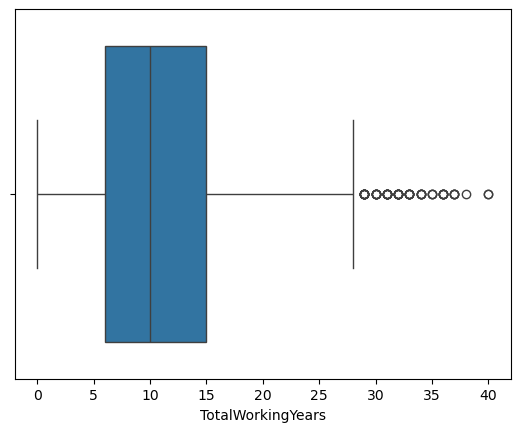

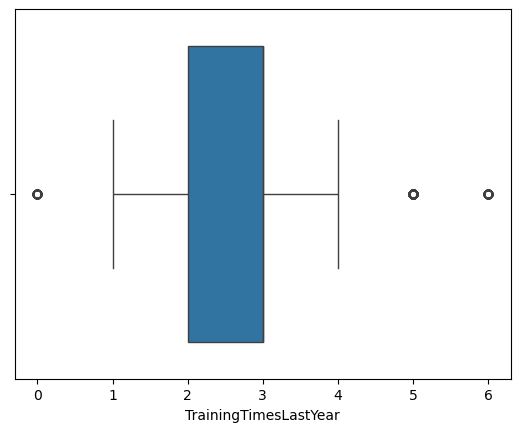

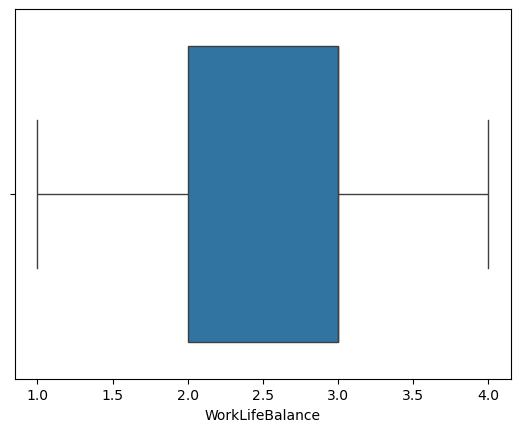

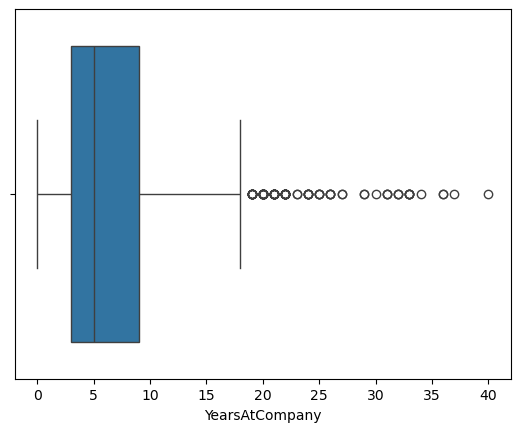

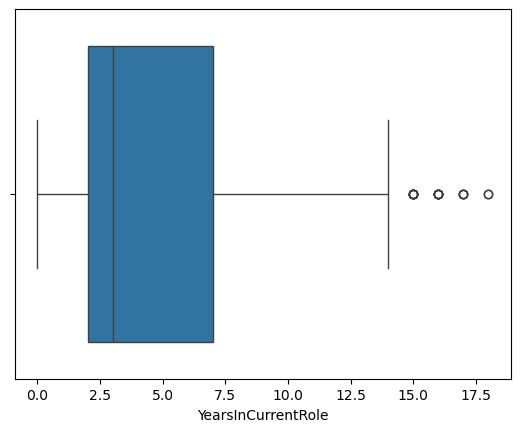

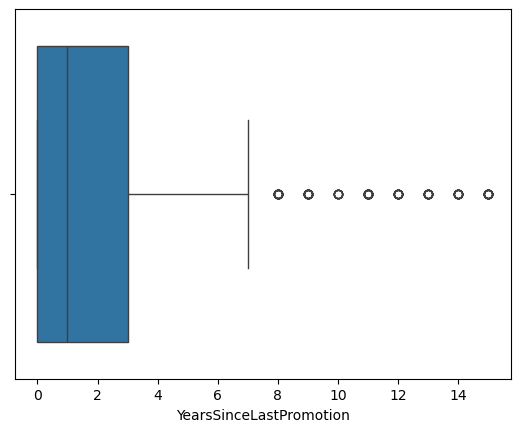

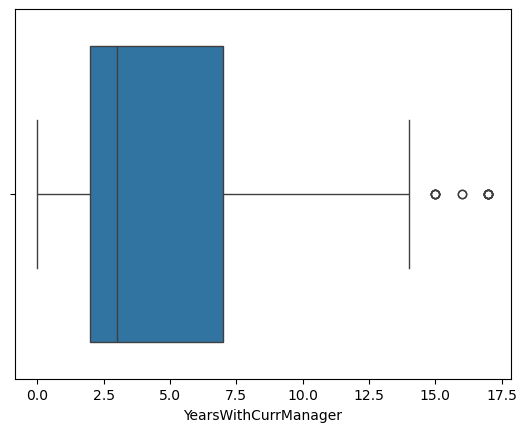

In [13]:
# checking outliers
numerical_cols = df.select_dtypes(include=np.number)
for col in numerical_cols:
    sns.boxplot(x=df[col])
    plt.show()

In [14]:
# variable classification
# numerical variables
numerical_continuous = ['Age', 'DailyRate',
       'DistanceFromHome',  'HourlyRate',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager']

In [15]:
# ordinal
ordinal_var = ['JobInvolvement', 'JobLevel', 'JobSatisfaction',
        'Education', 'EnvironmentSatisfaction', 'PerformanceRating',
       'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

In [16]:
# categorical(nominal)
categorical_nominal = ['BusinessTravel', 'Department', 'Gender', 'EducationField', 'JobRole', 'MaritalStatus', 'OverTime']

In [17]:
# target variable
target = "Attrition"

# leakage variables
# potential leakage variables:
1. EmployeeCount
2. Over18
3. StandardHours
4. EmployeeNumber
   
EmployeeCount, Over18, StandardHours they have zero variance hence in the model they will inflates complexity with zero information. EmployeeNumber is an ID , not a feature.

In [18]:
# near zero variance variables
for col in df.columns:
    print(col,df[col].nunique())

Unnamed: 0 1470
Age 43
Attrition 2
BusinessTravel 3
DailyRate 886
Department 3
DistanceFromHome 29
Education 5
EducationField 6
EmployeeCount 1
EmployeeNumber 1470
EnvironmentSatisfaction 4
Gender 2
HourlyRate 71
JobInvolvement 4
JobLevel 5
JobRole 9
JobSatisfaction 4
MaritalStatus 3
MonthlyIncome 1349
MonthlyRate 1427
NumCompaniesWorked 10
Over18 1
OverTime 2
PercentSalaryHike 15
PerformanceRating 2
RelationshipSatisfaction 4
StandardHours 1
StockOptionLevel 4
TotalWorkingYears 40
TrainingTimesLastYear 7
WorkLifeBalance 4
YearsAtCompany 37
YearsInCurrentRole 19
YearsSinceLastPromotion 16
YearsWithCurrManager 18


In [19]:
# drop zero variance leakage columns
df.drop(columns = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"], inplace = True)

In [20]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [21]:
# separate variables
categorical = df.select_dtypes(include="object").columns
numerical = df.select_dtypes(exclude="object").columns

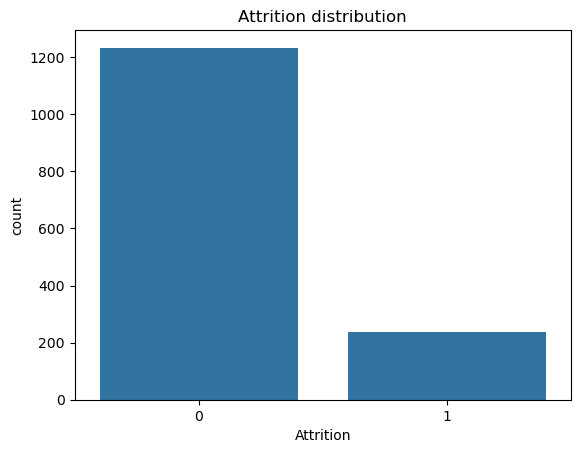

In [22]:
# explore outcomes
sns.countplot(x="Attrition", data=df)
plt.title("Attrition distribution")
plt.show()

In [23]:
# Creating contingency table
pd.crosstab(df["OverTime"], df["Attrition"])

Attrition,0,1
OverTime,,
0,944,110
1,289,127


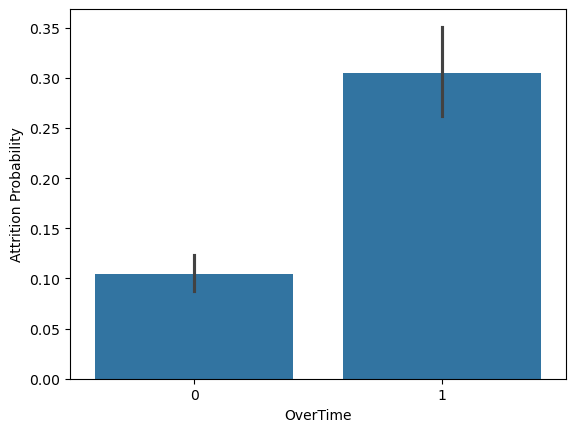

In [24]:
# Visualise
sns.barplot(x="OverTime", y="Attrition", data=df)
plt.ylabel("Attrition Probability")
plt.show()

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

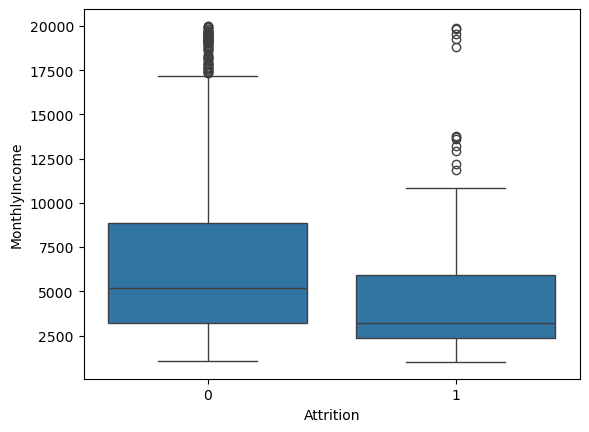

In [25]:
# visualise relationship with attrition
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

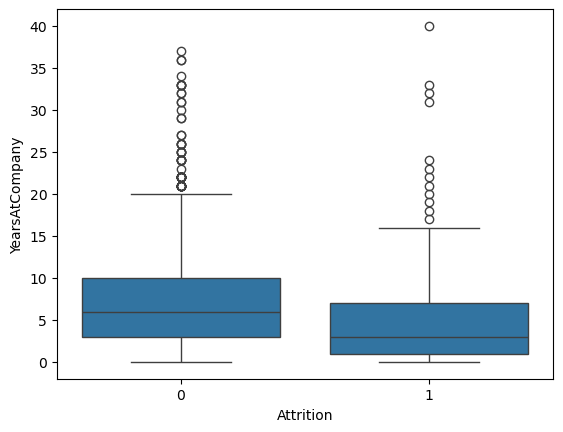

In [26]:
# visualise relationship with attrition
sns.boxplot(y="YearsAtCompany", x="Attrition", data=df)
            

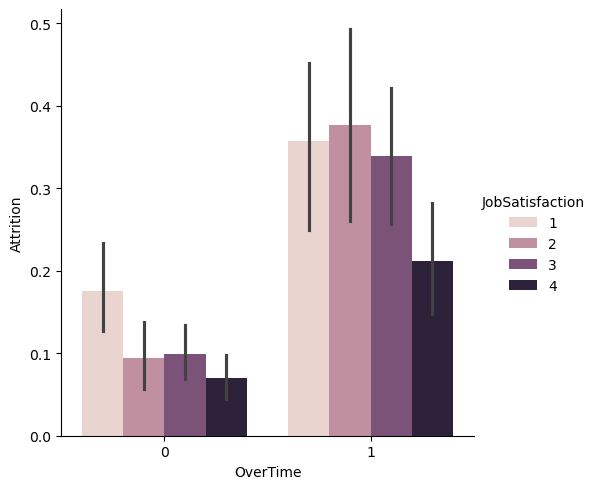

In [27]:
# visualise interaction effects: Overtime * Job Satisfaction
sns.catplot(x="OverTime", y="Attrition", hue="JobSatisfaction", kind="bar", data=df)

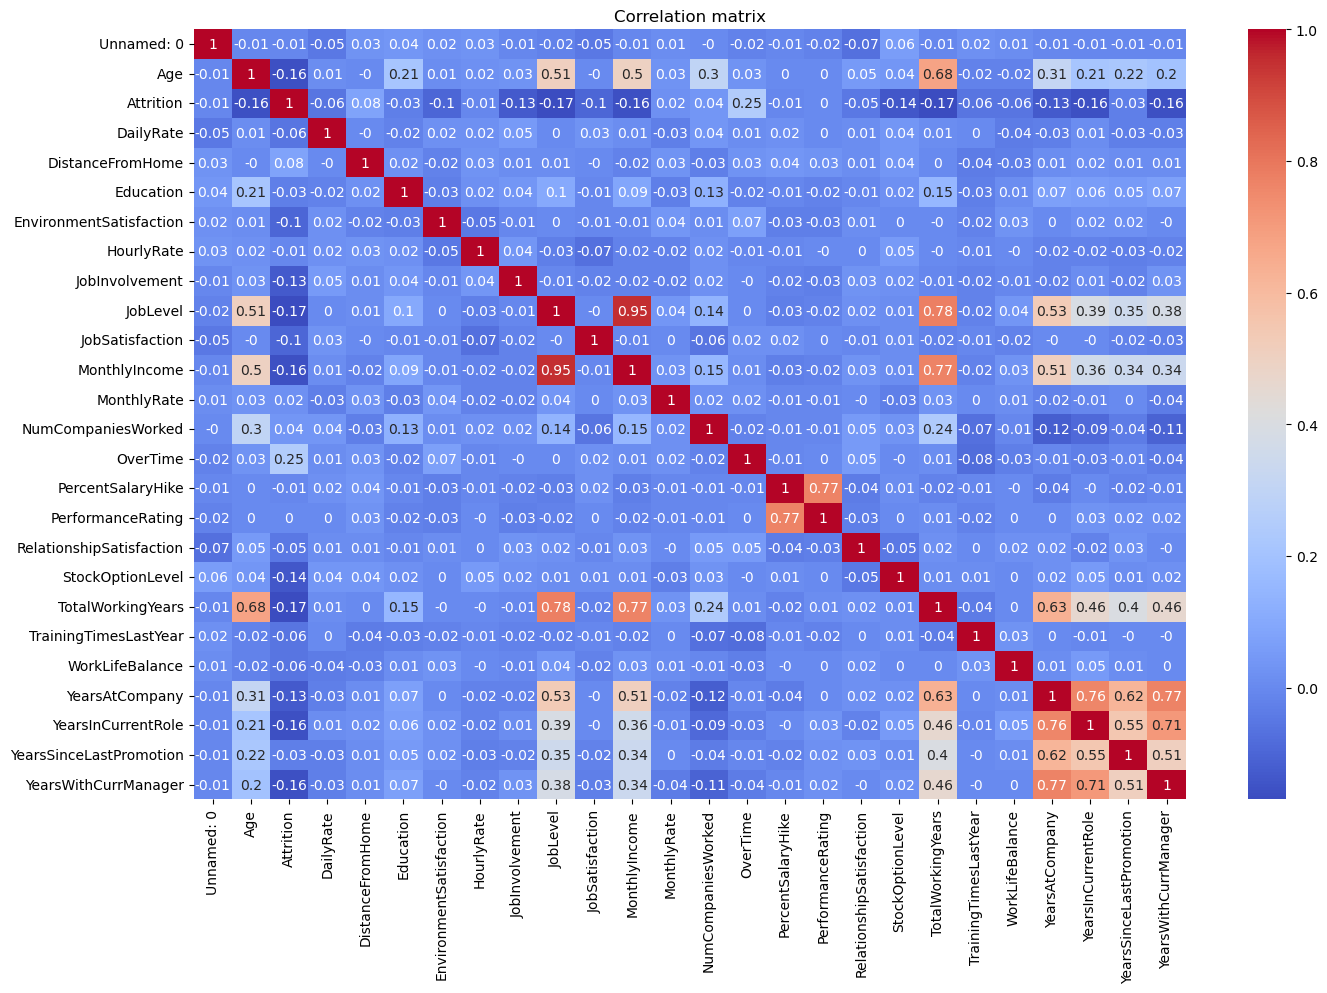

In [28]:
# compute the correlation matrix using only numeric columns
corr=df.corr(numeric_only=True)
# set the figure for heatmap
plt.figure(figsize=(16,10))
# create a heatmap of the correlation matrix
sns.heatmap(corr.round(2), annot=True, cmap="coolwarm")
# masking the upper triangle to avoid duplicate correlations
mask=np.triu(np.ones_like(corr, dtype=bool))
plt.title("Correlation matrix")
plt.savefig("results/figures/Correlation matrix.png",dpi=300,bbox_inches="tight")
plt.show()

<Axes: xlabel='Gender', ylabel='Attrition'>

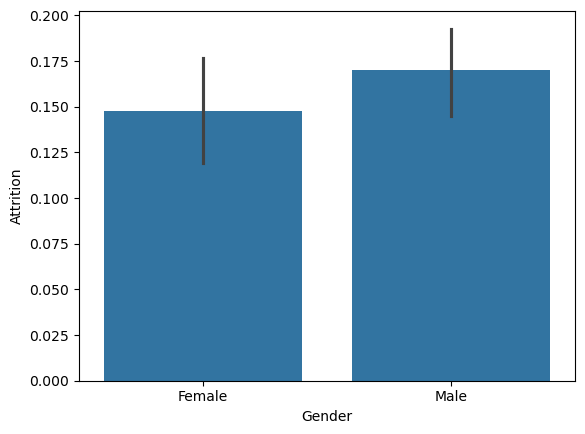

In [29]:
# visualise Attrition by Gender
sns.barplot(
    y="Attrition",
    x="Gender",
    data=df
)

<Axes: xlabel='MaritalStatus', ylabel='Attrition'>

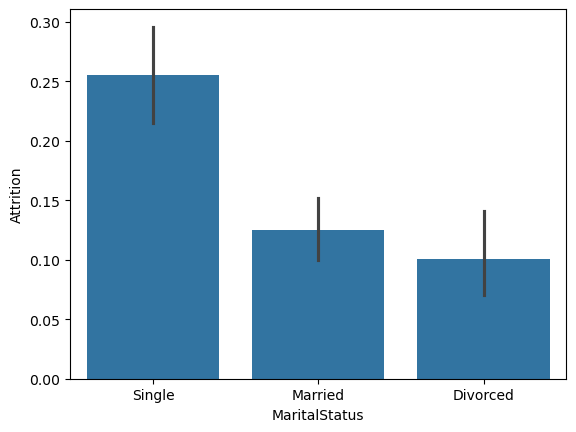

In [30]:
# visualise Attrition by MaritalStatus
sns.barplot(
    y="Attrition",
    x="MaritalStatus",
    data=df
)

<Axes: xlabel='Attrition', ylabel='JobRole'>

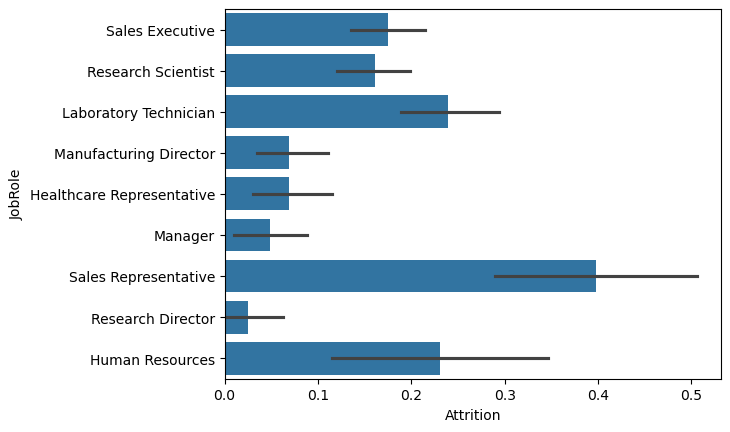

In [31]:
# visualise Attrition by JobRole
sns.barplot(
    y="JobRole",
    x="Attrition",
    data=df
)

<Axes: xlabel='Department', ylabel='Attrition'>

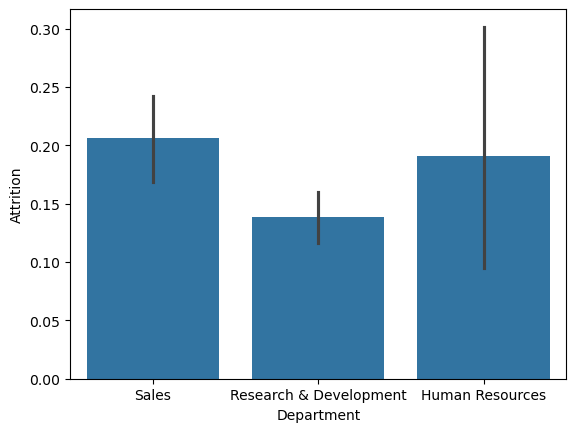

In [32]:
# visualise Attrition by department
sns.barplot(
    x="Department",
    y="Attrition",
    data=df
)

Why: This is because different teams often have different detection patterns.

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

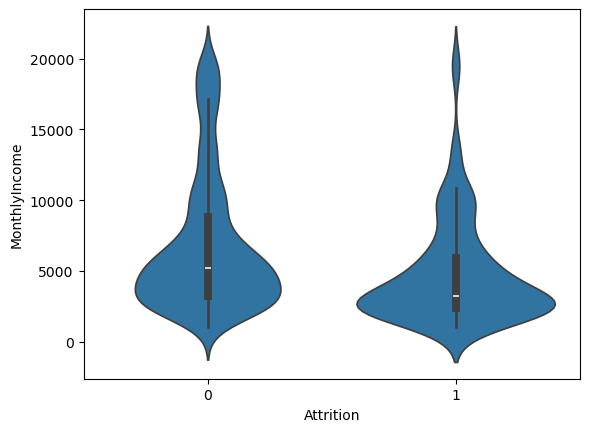

In [33]:
# visualise MonthlyIncome distributions
sns.violinplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

Why: This is because violin plots captures skewness better than boxplots.

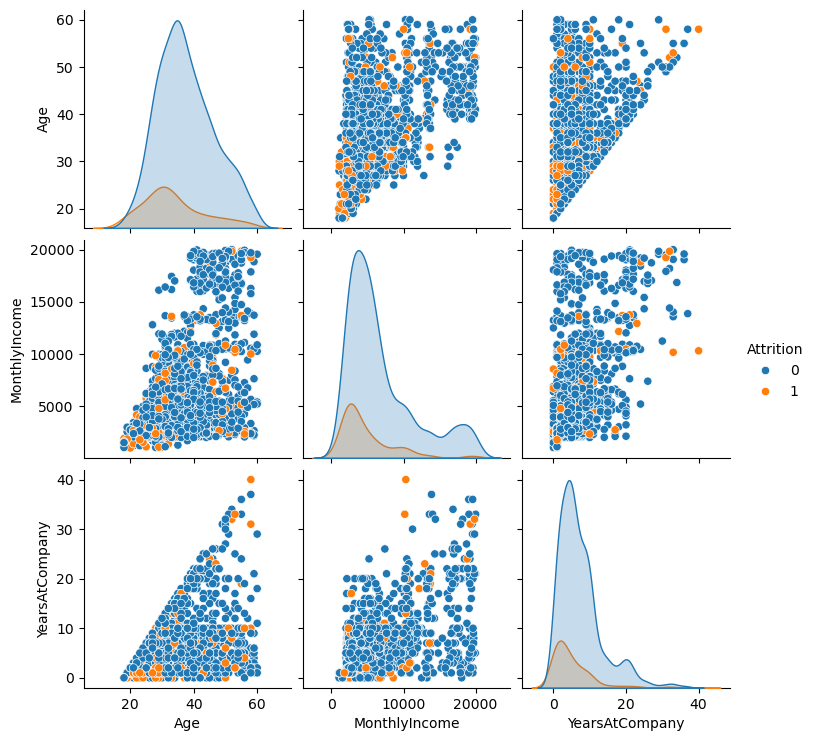

In [34]:
# visualise paired plot of selected predictors
sns.pairplot(
    df[
        ["Age",
        "MonthlyIncome",
        "YearsAtCompany",
        "Attrition"]
    ],
    hue="Attrition"
)

Employees working overtime exhibit substantially higher turnover risk , suggesting workload burden may be contributing to employee dissatisfaction and burn out.

In [35]:
# tenure groups
# Early stage: still exploring. Mid stage:peak risk. Senior: stabilized
df["TenureGroup"] = pd.cut(df["YearsAtCompany"], bins = [0,2,5,10,40], labels = ["New", "Early", "Mid", "Long"])
df["TenureGroup"]                       

0         Mid
1         Mid
2         NaN
3         Mid
4         New
        ...  
1465    Early
1466      Mid
1467      Mid
1468      Mid
1469    Early
Name: TenureGroup, Length: 1470, dtype: category
Categories (4, object): ['New' < 'Early' < 'Mid' < 'Long']

why: Attrition often peaks during early employment

In [36]:
# income bands
df["IncomeBand"] = pd.qcut(df["MonthlyIncome"], q = 4, labels = ["Low", "Medium", "High", "VeryHigh"])
df["IncomeBand"]

0           High
1           High
2            Low
3            Low
4         Medium
          ...   
1465         Low
1466    VeryHigh
1467        High
1468        High
1469      Medium
Name: IncomeBand, Length: 1470, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'VeryHigh']

why: This is because of nonlinear salary effects

In [37]:
# satisfaction index
df["SatisfactionIndex"] = (df["JobSatisfaction"] + df["EnvironmentSatisfaction"] + df["RelationshipSatisfaction"]) / 3
df["SatisfactionIndex"]

0       2.333333
1       3.000000
2       3.000000
3       3.333333
4       2.333333
          ...   
1465    3.333333
1466    2.000000
1467    2.000000
1468    3.333333
1469    2.000000
Name: SatisfactionIndex, Length: 1470, dtype: float64

why: This is because combined psychosocial measures often outperform isolated variables.

In [38]:
# overtime burden metric
df["OverTimeTenureInteraction"] = (df["OverTime"] + df["YearsAtCompany"])
df["OverTimeTenureInteraction"]

0        7
1       10
2        1
3        9
4        2
        ..
1465     5
1466     7
1467     7
1468     9
1469     4
Name: OverTimeTenureInteraction, Length: 1470, dtype: int64

why: This is because long term overtime may affect employees differently.

In [39]:
# promotion stagnation
df["PromotionStagnation"] = (df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1))
df["PromotionStagnation"]

0       0.000000
1       0.090909
2       0.000000
3       0.333333
4       0.666667
          ...   
1465    0.000000
1466    0.125000
1467    0.000000
1468    0.000000
1469    0.200000
Name: PromotionStagnation, Length: 1470, dtype: float64

why: This is because high stagnation relative to experience predicts attrition

In [40]:
# interaction terms
df["Income_JobLevel"] = (df["MonthlyIncome"] + df["JobLevel"])
df["Income_JobLevel"]                    

0       5995
1       5132
2       2091
3       2910
4       3469
        ... 
1465    2573
1466    9994
1467    6144
1468    5392
1469    4406
Name: Income_JobLevel, Length: 1470, dtype: int64

why: This is because income effects may differ across hierarchy levels.

In [41]:
# performing chi-square tests
cat_vars_test = ['BusinessTravel', 'Department', 'Gender', 'EducationField', 'JobRole', 'MaritalStatus', 'OverTime']
chi2_results = []
for var in cat_vars_test:
    table = pd.crosstab(df[var], df["Attrition"])
    chi2, p, dof, expected = chi2_contingency(table)
    # Cramer's V = effect size
    n = table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    chi2_results.append({
        "Variable" : var, "chi2" : round(chi2, 2), "p_value" : round(p, 4),
        "df" : dof, "Cramer's V" : round(cramers_v, 3)
    })
chi2_df = pd.DataFrame(chi2_results).sort_values("Cramer's V", ascending = False)
print(chi2_df.to_string(index = False))

      Variable  chi2  p_value  df  Cramer's V
      OverTime 87.56   0.0000   1       0.244
       JobRole 86.19   0.0000   8       0.242
 MaritalStatus 46.16   0.0000   2       0.177
BusinessTravel 24.18   0.0000   2       0.128
EducationField 16.02   0.0068   5       0.104
    Department 10.80   0.0045   2       0.086
        Gender  1.12   0.2906   1       0.028


In [42]:
# independent samples T-tests
stayed = df[df.Attrition==0]
left = df[df.Attrition==1]
num_vars_test = ['Age',
       'DistanceFromHome',
       'MonthlyIncome', 'NumCompaniesWorked',
       'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion']
ttest_results = []
for var in num_vars_test:
    t, p = ttest_ind(stayed[var], left[var])
    #Cohen's d = effect size
    pooled_sd = np.sqrt((stayed[var].var() + left[var].var()) / 2)
    cohens_d = abs(stayed[var].mean() - left[var].mean()) / pooled_sd
    ttest_results.append({
        "Variable" : var,
        "Mean(stayed)" : round(stayed[var].mean(), 2),
        "Mean(left)" : round(left[var].mean(), 2),
        "t-statistic" : round(t, 3),
        "p-value" : round(p, 4),
        "Cohen's d" : round(cohens_d, 3)
    })
ttest_df = pd.DataFrame(ttest_results).sort_values("Cohen's d", ascending = False)
print(ttest_df.to_string(index = False))

               Variable  Mean(stayed)  Mean(left)  t-statistic  p-value  Cohen's d
      TotalWorkingYears         11.86        8.24        6.652   0.0000      0.484
          MonthlyIncome       6832.74     4787.09        6.204   0.0000      0.479
                    Age         37.56       33.61        6.179   0.0000      0.425
         YearsAtCompany          7.37        5.13        5.196   0.0000      0.372
       DistanceFromHome          8.92       10.63       -2.995   0.0028      0.209
  TrainingTimesLastYear          2.83        2.62        2.283   0.0226      0.164
     NumCompaniesWorked          2.65        2.94       -1.668   0.0955      0.115
YearsSinceLastPromotion          2.23        1.95        1.266   0.2058      0.091


In [43]:
# ANOVA
f_oneway(df[df.JobRole=="Sales Executive"]["MonthlyIncome"], df[df.JobRole=="Research Scientist"]["MonthlyIncome"])

F_onewayResult(statistic=np.float64(575.3668764542292), pvalue=np.float64(2.710899588852469e-90))

In [44]:
# multicollinearity check
model_vars = ['Age', 'Attrition',
       'JobSatisfaction',
        'MonthlyIncome',  'OverTime', 'TotalWorkingYears', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'DistanceFromHome']
X_vif = df[model_vars].dropna().copy()
X_vif = sm.add_constant(X_vif)
vif_data = pd.DataFrame({
    "Feature" : X_vif.columns,
    "VIF" :[variance_inflation_factor(X_vif.values, i)
           for i in range(X_vif.shape[1])]
})
print(vif_data.sort_values("VIF", ascending = False))

                    Feature        VIF
0                     const  48.473376
6         TotalWorkingYears   4.418047
4             MonthlyIncome   2.513350
8            YearsAtCompany   2.332761
1                       Age   1.963214
9   YearsSinceLastPromotion   1.632096
2                 Attrition   1.141826
5                  OverTime   1.074070
3           JobSatisfaction   1.016352
7           WorkLifeBalance   1.008453
10         DistanceFromHome   1.007942


# why VIF matters here
Age,TotalWorkingYears, and YearsAtCompany are highly correlated. Including all three  inflates standard errors, makes CIs wide, and makes OR interpretation unreliable.

# Build the Logistic Regression model
# Select variables:
1. Overtime is the main exposure of interest
2. Age is the career stage effect
3. MonthlyIncome is the economic factor
4. JobSatisfaction is the psychosocial factor
5. YearsAtCompany is the retention effect
6. WorkLifeBalance is the behavioral stress factor


In [45]:
# create a working dataset
model_df = df[['Age', 'Attrition',
       'JobSatisfaction',
        'MonthlyIncome',  'OverTime',  'WorkLifeBalance',
       'YearsAtCompany', ]].copy()
model_df

,Age,Attrition,JobSatisfaction,MonthlyIncome,OverTime,WorkLifeBalance,YearsAtCompany
0,41,1,4,5993,1,1,6
1,49,0,2,5130,0,3,10
2,37,1,3,2090,1,3,0
3,33,0,3,2909,1,3,8
4,27,0,2,3468,0,3,2
...,...,...,...,...,...,...,...
1465,36,0,4,2571,0,3,5
1466,39,0,1,9991,0,3,7
1467,27,0,2,6142,1,3,6
1468,49,0,2,5390,0,2,9


In [46]:
# define X and Y and adding x intercept
y = model_df["Attrition"]
x = model_df.drop("Attrition", axis=1)
X = sm.add_constant(x)

In [47]:
# fit Logistic Regression (inference model and not ML Model)
logit_model = sm.Logit(y, X)
result = logit_model.fit()

Optimization terminated successfully.
         Current function value: 0.381917
         Iterations 7


In [48]:
# print results, the table is scientific output
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:              Attrition   No. Observations:                 1470
Model:                          Logit   Df Residuals:                     1463
Method:                           MLE   Df Model:                            6
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.1353
Time:                        13:51:19   Log-Likelihood:                -561.42
converged:                       True   LL-Null:                       -649.29
Covariance Type:            nonrobust   LLR p-value:                 2.713e-35
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.2835      0.481      2.670      0.008       0.341       2.226
Age                -0.0365      0.010     -3.635      0.000      -0.056      -0.017
JobSatisfaction    -0.3085      

the coefficients are in log-odds, which are not intuitive so we need to convert to Odds Ratios, so that interpretation becomes natural.

In [49]:
# convert coeficients to odds ratios
odds_ratios = np.exp(result.params)
print(odds_ratios)

const              3.609186
Age                0.964169
JobSatisfaction    0.734563
MonthlyIncome      0.999926
OverTime           4.290160
WorkLifeBalance    0.767825
YearsAtCompany     0.961462
dtype: float64


In [50]:
# Confidence interval
conf = result.conf_int()
conf["OR"] = odds_ratios
conf.columns = ["2.5%", "97.5%", "OR"]
print(np.exp(conf))

                     2.5%     97.5%         OR
const            1.406958  9.258435  36.935979
Age              0.945383  0.983328   2.622607
JobSatisfaction  0.642915  0.839276   2.084571
MonthlyIncome    0.999874  0.999977   2.718080
OverTime         3.167573  5.810589  72.978110
WorkLifeBalance  0.624460  0.944104   2.155074
YearsAtCompany   0.927186  0.997005   2.615517


In [51]:
# split data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, stratify = y, random_state = 42)
print(f"Train set : {X_train.shape[0]} rows | "
     f"Attrition rate : {y_train.mean() : 2%}")
print(f"Test set : {X_test.shape[0]} rows | "
     f"Attrition rate : {y_test.mean() : 2%}")


Train set : 1176 rows | Attrition rate :  16.156463%
Test set : 294 rows | Attrition rate :  15.986395%


In [52]:
# SMOTE
smote = SMOTE(random_state = 42)
# balance only the training data
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE: {pd.Series(y_train_sm).value_counts().to_dict()}")


After SMOTE: {0: 986, 1: 986}


SMOTE only on training data , never on test data (data leakage)


In [53]:
# scale for LR and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

In [54]:
# convert back to DataFrame so the feature names remain intact for SHAP
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [55]:
# evaluate predictive performance (not for causation , but completeness)
pred_probs = result.predict(X)
auc = roc_auc_score(y, pred_probs)
print("AUC:", auc)

AUC: 0.7594936708860759


In [56]:
# model training
models = {"Logistic Regression" : LogisticRegression(max_iter = 1000, random_state = 42),
         "Random Forest" : RandomForestClassifier(n_estimators = 200, random_state = 42,
                                                 class_weight = "balanced"),
          "Gradient Boosting" : GradientBoostingClassifier(n_estimators = 200,
                                                          random_state = 42),
         "SVM" : SVC(probability = True, class_weight = "balanced",
                    random_state = 42)
}
print("5-Fold Cross-Validation (AUC_ROC) on SMOTE-balanced training data : \n")
cv_results = {}
for name, clf in models.items() :
    cv_scores = cross_val_score(
        clf,
        X_train_scaled,
        y_train_sm,
        cv = 5,
        scoring = "roc_auc"
    )
    cv_results[name] = cv_scores
    print(f"{name:25s} | Mean AUC : {cv_scores.mean() : .4f} | std : {cv_scores.std() : .4f}")


5-Fold Cross-Validation (AUC_ROC) on SMOTE-balanced training data : 

Logistic Regression       | Mean AUC :  0.7974 | std :  0.0557
Random Forest             | Mean AUC :  0.9012 | std :  0.0467
Gradient Boosting         | Mean AUC :  0.8754 | std :  0.0588
SVM                       | Mean AUC :  0.8336 | std :  0.0570


In [57]:
# fit each model and store results for evaluation
results = {}
for name, clf in models.items() : 
    clf.fit(X_train_scaled, y_train_sm)
    preds = clf.predict(X_test_scaled)
    probs = clf.predict_proba(X_test_scaled)[: , 1]
    results[name] = {
        "preds": preds,
        "probs": probs,
        "AUC_ROC": round(roc_auc_score(y_test, probs), 4),
        "F1": round(f1_score(y_test, preds), 4),
         "Recall": round(recall_score(y_test, preds), 4),
    }
    print(f"{name:25s} | AUC: {results[name]["AUC_ROC"]} | "
         f"F1: {results[name]["F1"]} | Recall: {results[name]["Recall"]}")

Logistic Regression       | AUC: 0.6635 | F1: 0.4 | Recall: 0.617
Random Forest             | AUC: 0.6597 | F1: 0.2903 | Recall: 0.383
Gradient Boosting         | AUC: 0.6507 | F1: 0.3538 | Recall: 0.4894
SVM                       | AUC: 0.6696 | F1: 0.3673 | Recall: 0.5745


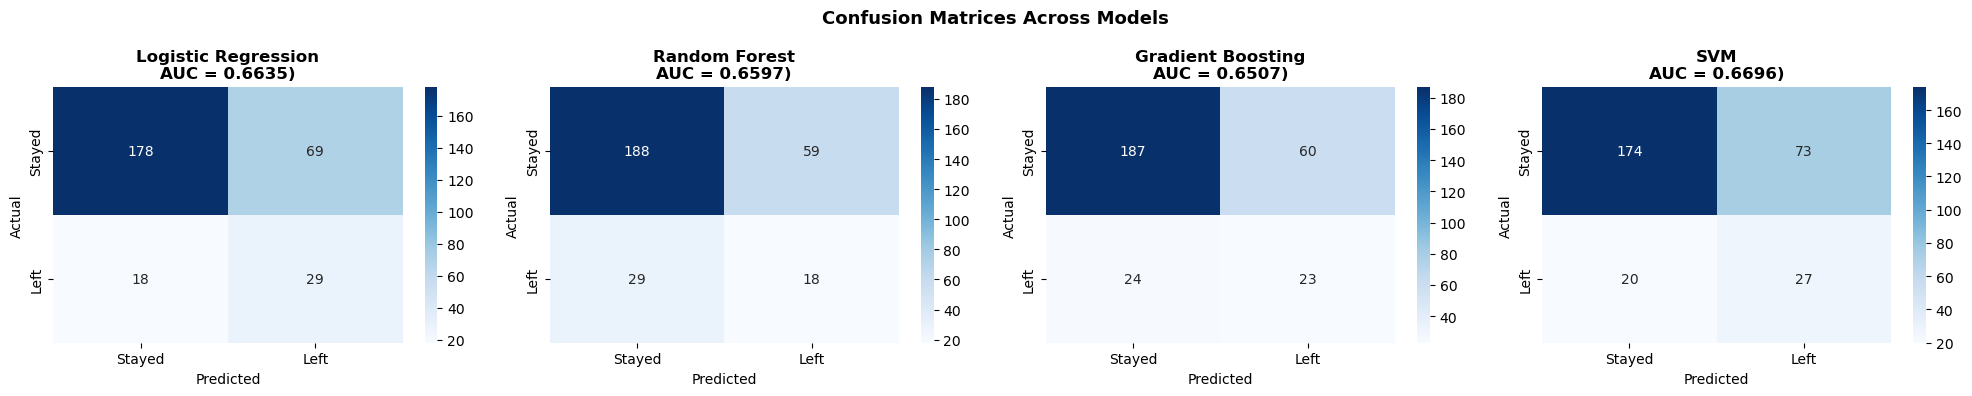

In [58]:
# evaluation
# confusion matrices for each model
fig, axes = plt.subplots(1, len(models), figsize = (20, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["preds"])
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", ax = ax,
               xticklabels = ["Stayed", "Left"],
               yticklabels = ["Stayed", "Left"])
    ax.set_title(f"{name}\nAUC = {res["AUC_ROC"]})", fontweight = "bold")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.suptitle("Confusion Matrices Across Models", fontweight = "bold", fontsize = 13)
plt.tight_layout()
plt.savefig("results/figures/Confusion Matrices Across Models.png",dpi=300,bbox_inches="tight")
plt.show()

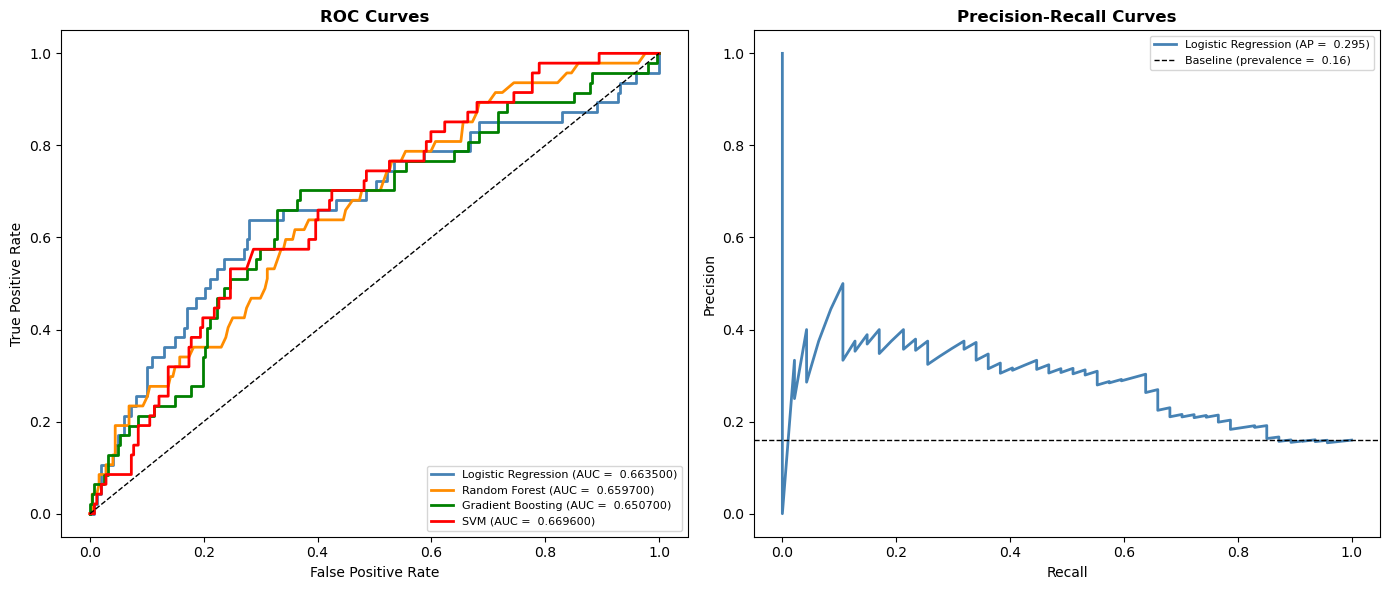

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [59]:
# ROC CURVES, all models on one plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize =(14, 6))
colors = ["steelblue", "darkorange", "green", "red", "purple"]
for (name, res), color in zip(results.items(), colors) : 
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    ax1.plot(fpr, tpr, color = color, lw = 2,
            label = f"{name} (AUC = {res["AUC_ROC"] : 3f})")
ax1.plot([0,1],[0,1], "k--", lw = 1)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves", fontweight = "bold")
ax1.legend(loc = "lower right", fontsize = 8)
# Precision recall curves
for (name, res), color in zip(results.items(), colors) :
    precision, recall, _ = precision_recall_curve(y_test, res["probs"])
    ap = average_precision_score(y_test, res["probs"])
    ax2.plot(recall, precision, color = color, lw = 2,
            label = f"{name} (AP = {ap : .3f})")
    ax2.axhline(y_test.mean(), linestyle = "--", color = "black", linewidth = 1,
               label = f"Baseline (prevalence = {y_test.mean() : .2f})")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Precision")
    ax2.set_title("Precision-Recall Curves", fontweight = "bold")
    ax2.legend(loc = "upper right", fontsize = 8)
    plt.tight_layout()
    plt.savefig("results/figures/ROC Curves and Precision recall curves.png",dpi=300,bbox_inches="tight")
    plt.show()

In [60]:
# SHAP values , with Random Forest it is best balance of accuracy + interpretability
rf_model = models["Random Forest"]

In [61]:
# TreeExplainer is fast and exact for tree-based models
explainer = shap.TreeExplainer(rf_model)
shap_values =explainer.shap_values(X_test_scaled)

In [62]:
# for binary classification, shap_values is a list [clas_0, class_1]
shap_vals_attrition = shap_values[1]